#CH7 군집화 (03~04)
###03. 평균 이동


평균 이동은 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행한다. 하지만 K-평균이 중심에 소속된 데이터의 평균 거리 중심으로 이동하는 데 반해, 평균 이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킨다.

평균 이동 군집화는 데이터의 분포도를 이용해 군집 중심점을 찾는다. 군집 중심점은 데이터 포인트가 모여있는 곳이라는 생각에서 착안한 것으로 이를 위해 **확률 밀도 함수**를 이용한다. 가장 집중적으로 데이터가 모여 있어 확률 밀도 함수가 피크인 점을 군집 중심점으로 선정하며 일반적으로 주어진 모델의 확률 밀도 함수를 찾기 위해 KDE를 이용한다

* KDE: Kernel Density Estimation

평균 이동 군집화는 특정 데이터를 반경 내 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 이해 주변 데이터와의 거리 값은 KDE함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동하는 방식을 취한다. 이러한 방식을 전체 데이터에 반복적으로 적용하면서 데이터의 군집 중심점을 찾아낸다.

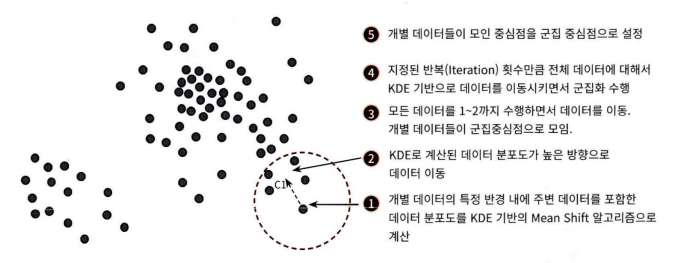

KDE는 커널 함수를 통해 어떤 변수의 확률 밀도 함수를 추정하는 대표적인 방법이다. 관측된 데이터 각각에 커널 함수를 적용한 값을 모두 더한 뒤 데이터 건수로 나눠 확률 밀도 함수를 추정한다.

KDE는 개별 관측 데이터에 커널 함수를 적용한 뒤, 이 적용값을 모두 더한 후 개별 관측 데이터의 건수로 나눠 확률 밀도 함수를 추정한다. 대표적인 커널 함수로 가우시안 분포 함수가 사용된다.

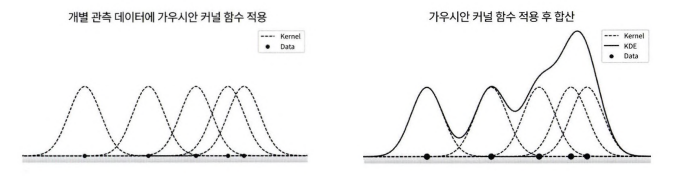

$$\text{KDE} = \frac{1}{n} \sum_{i=1}^{n} K_h(x - x_i) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

대역폭 $h$는 KDE 형태를 부드러운 또는 뾰족한 형태로 평활화 (Smoothing)하는 데 적용되며, 이 $h$를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능을 크게 좌우할 수 있다.

작은 $h$값은 좁고 뾰족한 KDE를 가지게 되고 이는 변동성이 큰 방식으로 확률 밀도 함수를 추정하므로 **과적합**하기 쉽다. 반대로 매우 큰 $h$값은 과도하게 평활화된 KDE로 인해 지나치게 단순화된 방식으로 확률 밀도 함수를 추정하며 결과적으로 **과소적합**하기 쉽다.

대역폭 크기 설정이 군집화의 품질에 큰 영향을 미치기 때문에 사이킷런은 최적의 대역폭 계산을 위해 ```estimate_bandwith()```함수를 제공한다.

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X,y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)

meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [4]:
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [6]:
from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth,3))

bandwidth 값: 1.816


In [7]:
import pandas as pd

clusterDF= pd.DataFrame(data=X, columns=['ftr1','ftr2'])
clusterDF['target'] = y
#estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


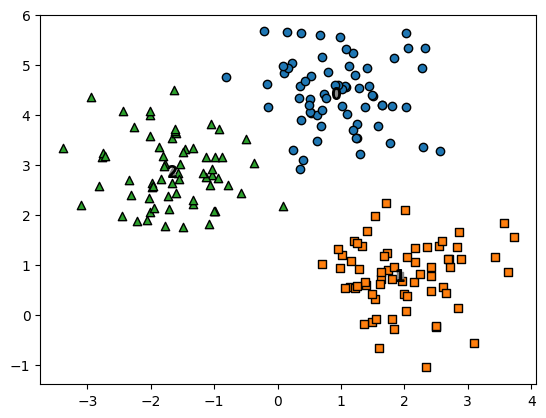

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label'] ==label]
    center_x_y = centers[label]

    #군집별로 다른 마커로 산점도 적용
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

    #군집별 중심 표현
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=20, color='gray', alpha=0.9,
                marker= markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',edgecolor='k', marker='$%d$'%label)

plt.show()

In [10]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


평균 이동의 장점은 데이터 세트의 형태를 특정 형태로 가정하거나 특정 분포도 기반의 모델로 가정하지 않기 때문에 더 유연한 군집화가 가능하다.

또한 이상치의 영향력도 크지 않으며 미리 군집의 개수를 정할 필요도 없다. 하지만 알고리즘의 수행 시간이 오래 걸리고 무엇보다 band_width의 크기게 따른 군집화 영향도가 크다.

**평균 이동 군집화 기법**은 분석 업무 기반의 데이터 세트보다는 **컴퓨터 비전 영역에서 더 많이 사용**

###04. GMM (Gaussian Mixture Model)

GMM군집화는 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포를 가진 데이터 집합들이 섞여서 생성된 것이라는 가정하에 군집화를 수행하는 방식이다.

정규 분포로 알려진 가우시안 분포는 좌우대칭형의 종 형태를 가진 통계학에서 가장 잘 알려진 연속 확률 함수이다.

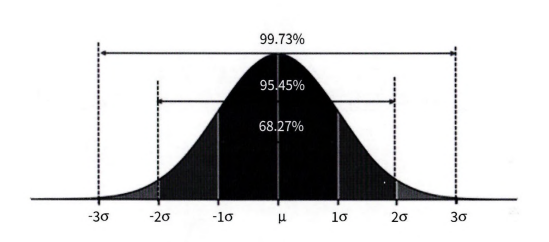

GMM은 데이터를 여러 개의 가우시안 분포가 섞인 것으로 간주한다. 섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출한다.

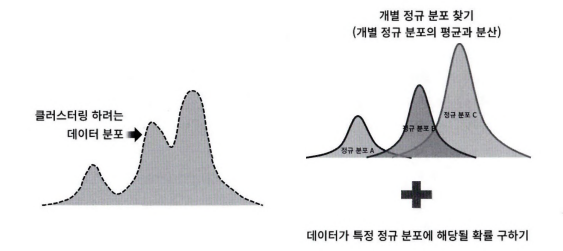

전체 데이터 세트를 서로 다른 정규 분포 형태를 가진 여러 가지 확률 분포 곡선으로 구성될 수 있으며, 이러한 서로 다른 정규 분포에 기반해 군집화를 수행하는 것이 GMM 군집화 방식이다. 가령 1000개의 데이터 세트가 있다면 이를 구성하는 여러 개의 정규 분포 곡선을 추출하고, 개별 데이터가 이 중 어떤 정규 분포에 속하는지 결정하는 방식이다.

이와 같은 방식을 GMM에서는 **모수 추정**이라고 하는데 대표적으로 **2가지**를 추정한다.

1. 개별 정규 분포의 평균과 분산
2. 각 데이터가 어떤 정규 분포에 해당되는지의 확률

모수추정을 위해 GMM은 **EM(Expectation and Maximazation)** 방법 적용

###GMM을 이용한 붓꽃 데이터 세트 군집화

In [15]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['Sepal_length', 'Sepal_width','Petal_length','Petal_width']

#좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

In [16]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

#군집화 결과를 irisDF의 'gmm_cluster'칼럼명으로 저장
irisDF['gmm_clsuter'] = gmm_cluster_labels
irisDF['target'] = iris.target

#target값에 따라 gmm_cluster값이 어떻게 매핑되었는지 확인
iris_result = irisDF.groupby(['target'])['gmm_clsuter'].value_counts()
print(iris_result)

target  gmm_clsuter
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [19]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


### GMM과 K-평균의 비교

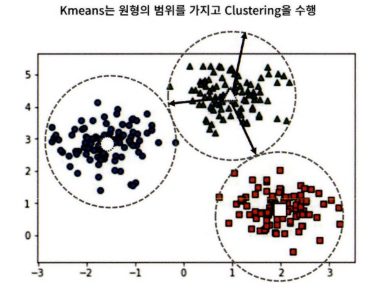

K-평균은 원형의 범위로 데이터를 군집화 하기 때문에 길쭉한 타원형으로 늘어선 경우 군집화를 잘 수행하지 못한다.

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
  if dataframe is None:
    print('Error: DataFrame is required.')
    return

  unique_labels = np.unique(dataframe[label_name])
  markers = ['o','s','^','x','*','D', '+', 'v', '<', '>']

  for label in unique_labels:
    label_cluster = dataframe[dataframe[label_name] == label]

    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k',
    marker=markers[label % len(markers)])

    if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
      # Assuming cluster_result has a .cluster_centers_ attribute
      center_x_y = cluster_result.cluster_centers_[label]

      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9,
      marker=markers[label % len(markers)])
      plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k',
      marker='$%d$' % label)

  plt.show()


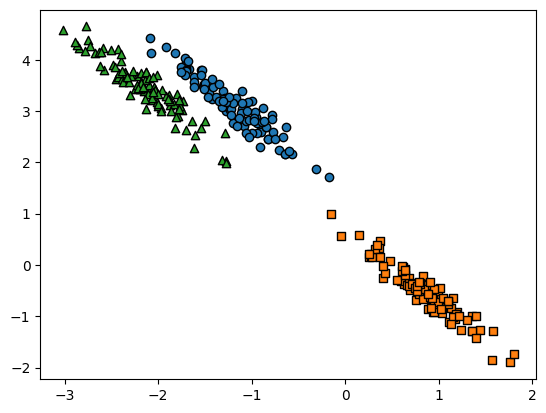

In [29]:
from sklearn.datasets import make_blobs

#make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std=0.5를 만듦
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

#길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X_aniso = np.dot(X, transformation)

#feature 데이터 세트와 make_blobs()의 y결괏값을 DataFrmae으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns = ['ftr1','ftr2'])
clusterDF['target']=y

#생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화
visualize_cluster_plot(None, clusterDF,'target',iscenter=False)

K-Means

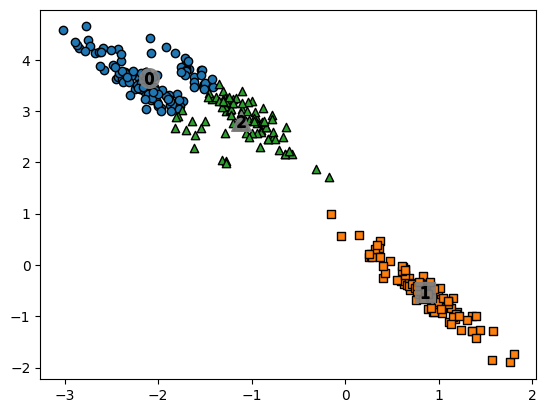

In [32]:
# 3개의 군집 기반 KMeans를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

GMM

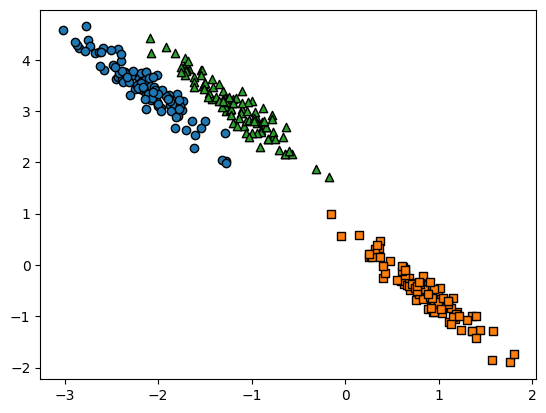

In [34]:
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label'] = gmm_label

#GaussianMixture는 cluster_centers_속성이 없으므로 iscenter를 False로 설정
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

make_blobs()의 target 값과 KMeans, GMM의 군집 Label 값을 서로 비교

In [37]:
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


KMeans의 경우 군집 1번만 정확히 매핑되었지만, 나머지 군집의 경우 target값과 어긋나는 경우가 발생하고 있다. 하지만 GMM의 경우 군집이 target값과 잘 매핑되어 있다.

이처럼 GMM의 경우 KMeans보다 유연하게 다양한 데이터 세트에 잘 적용될 수 있다는 장점이 있다. 하지만 수행시간이 오래 걸린다는 단점도 존재한다.